# Workshop: Rapid Application Development using Large Language Models
## Part 2: Generative Models and Multimodality

Practical session (60 min)

This notebook is part of a workshop based on NVIDIA DLI materials
"Rapid Application Development using Large Language Models",
adapted for Google Colab with a T4 GPU.

Credits: Original course materials by NVIDIA Corporation / NVIDIA Deep Learning Institute.

### Learning Objectives

By the end of this notebook you will be able to:

- Use GPT-2 to generate text and understand how sampling parameters change the output
- Use T5 to translate and summarize text with task prefixes
- Use CLIP to compare the similarity between images and text descriptions
- Use a ViT + GPT-2 model to generate captions for images
- Use Whisper to transcribe speech to text

In [1]:
# Run this cell first to install required packages
!pip install -q transformers datasets sentencepiece

In [2]:
import torch

print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU model  :", torch.cuda.get_device_name(0))
    print("GPU memory :", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), "GB")

GPU available: True
GPU model  : Tesla T4
GPU memory : 15.6 GB


---

## Part 2.1: Text Generation with GPT-2

In Part 1, we used BERT to understand text.
BERT reads the whole sentence at once (bidirectional).
This is good for classification but it cannot generate new text.

To generate text, we need a **decoder model**.
A decoder predicts one token at a time, always moving forward.
It uses only the tokens that came before the current position.

**GPT-2** is a decoder-only model trained on a large amount of internet text.
Given a starting prompt, it predicts the next most likely token,
adds it to the sequence, and repeats until it reaches the maximum length.

This process is called **autoregressive generation**.

In [6]:
from transformers import pipeline, set_seed

# Other decoder models for Google Colab T4:
#
# --- English only ---
#   "gpt2"                117M params, fast
#   "gpt2-medium"         345M params, better quality
#   "gpt2-large"          774M params, slower
#   "distilgpt2"          82M params, fastest
#
# --- Multilingual, small (load as-is, no extra flags) ---
#   "bigscience/bloom-560m"           560M params, 46 languages, Apache 2.0
#   "bigscience/bloom-1b7"            1.7B params, 46 languages, Apache 2.0
#   "facebook/xglm-564M"              564M params, 30 languages, MIT
#   "facebook/xglm-1.7B"              1.7B params, 30 languages, MIT
#   "Qwen/Qwen2.5-0.5B"               0.5B params, Chinese + English + others, Apache 2.0
#   "Qwen/Qwen2.5-1.5B"               1.5B params, same language coverage, Apache 2.0
#   "HuggingFaceTB/SmolLM2-1.7B-Instruct"   1.7B, 6 European languages, Apache 2.0
#
# --- Multilingual, medium (use torch_dtype=torch.float16 to fit on T4) ---
#   "Qwen/Qwen2.5-3B"                 3B params, Apache 2.0
#   "microsoft/Phi-3.5-mini-instruct" 3.8B params, multilingual, MIT
#   "HuggingFaceTB/SmolLM3-3B"        3B params, 6 European languages + tool calling, Apache 2.0
#
# --- Multilingual, larger (fp16 required, tight on T4 at ~14 GB) ---
#   "mistralai/Mistral-7B-v0.1"       7B params, multilingual, Apache 2.0
#   "Qwen/Qwen2.5-7B"                 7B params, very strong multilingual, Apache 2.0
#
# Note: models above 2B params should be loaded with torch_dtype=torch.float16:
#   generator = pipeline("text-generation", model="...", torch_dtype=torch.float16, device=0)
#
# Note: Llama and Gemma models require accepting a license on HuggingFace first
#   and passing a token: pipeline(..., token="hf_...")

generator = pipeline("text-generation", model="gpt2-medium", device=0)
print("Model loaded.")

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Model loaded.


In [7]:
# Basic text generation
# The model continues the prompt by predicting the most likely next tokens

set_seed(42)  # fix the random seed so results are the same each run

prompt = "The future of artificial intelligence is"

outputs = generator(
    prompt,
    max_new_tokens=40,
    num_return_sequences=3,   # generate 3 different completions
    do_sample=True,           # use random sampling (not greedy)
)

print(f"Prompt: {prompt!r}\n")
for i, out in enumerate(outputs):
    text = out["generated_text"][len(prompt):]   # show only the new part
    print(f"Completion {i+1}: {text.strip()}")
    print()

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=40) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Prompt: 'The future of artificial intelligence is'

Completion 1: so exciting that we can't resist talking about it. It's an exciting technology and if you look back at the history of AI, there have been two main types of AI, each with significant benefits

Completion 2: looking like this:

It's not a new idea, but it's one that's actually starting to get people excited.

"There's this kind of hype around artificial intelligence," says

Completion 3: increasingly about building machines that can understand how they think, what they think, how we think, and what we want from them. The question is how we design those machines to take into account our desires



### Sampling Parameters

The model does not always pick the single most likely next token.
It samples from a probability distribution over all tokens.
We can control this distribution with three main parameters:

| Parameter | What it does |
|---|---|
| `temperature` | Low values (e.g. 0.1) make the output more focused and repetitive. High values (e.g. 1.5) make it more creative and unpredictable. |
| `top_k` | Only the top k most likely tokens are considered. Smaller k = more focused. |
| `top_p` | Only tokens whose probabilities add up to p are considered. This is called nucleus sampling. |

Setting `temperature=0` or `do_sample=False` gives **greedy decoding**:
the model always picks the single most likely token. The output is always the same.

In [8]:
prompt = "Scientists have discovered a new planet that"

settings = [
    {"label": "greedy (no sampling)", "do_sample": False},
    {"label": "temperature = 0.3", "do_sample": True, "temperature": 0.3},
    {"label": "temperature = 1.0", "do_sample": True, "temperature": 1.0},
    {"label": "temperature = 1.5", "do_sample": True, "temperature": 1.5},
    {"label": "top_k = 5", "do_sample": True, "temperature": 1.0, "top_k": 5},
    {"label": "top_p = 0.9", "do_sample": True, "temperature": 1.0, "top_p": 0.9},
]

set_seed(42)

for s in settings:
    label = s.pop("label")
    out = generator(prompt, max_new_tokens=30, **s)[0]["generated_text"]
    continuation = out[len(prompt):]
    print(f"[{label}]")
    print(f"  {continuation.strip()}")
    print()

[transformers] Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=30) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Passing `generation_config` together with generation-related arguments=({'do_sample', 'temperature', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end genera

[greedy (no sampling)]
  is so hot that it could be a "super-Earth" that could host life.

The planet, named Kepler-186f, is



[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=30) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[temperature = 0.3]
  is the closest to our solar system, and it's a rocky world that is also very similar to Earth.

The planet, called Kepler-



[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=30) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[temperature = 1.0]
  's as close as nine light years away, and it's named after the famous author of a seminal science novel.

The newly discovered planet —



[transformers] Passing `generation_config` together with generation-related arguments=({'do_sample', 'temperature', 'top_k', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=30) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[temperature = 1.5]
  isn. They're describing a newly discovered new giant moon or worlds with the name Europa — in many minds this is one that's right up there where



[transformers] Passing `generation_config` together with generation-related arguments=({'do_sample', 'temperature', 'top_p', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=30) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[top_k = 5]
  orbits a star that has been in a state that's very similar to our own. Called HD 170533b, the planet is a little more

[top_p = 0.9]
  is so cold and dark that it is covered in dense ice and has an atmosphere that could support life," says study lead author David Saper, a



---

### Exercise 1: Text Generation

**Tasks:**
1. Change the prompt to something of your own and run the cell again
2. Set `temperature=0.1` and run three times. Are the results similar?
3. Set `temperature=1.5` and run three times. Are they more different?
4. Try `top_k=3` vs `top_k=100` and compare the outputs

In [13]:
#set_seed(42)  # remove fixed seed so each run gives different results

my_prompt = "The best way to learn machine learning is"  # TODO: change this

output = generator(
    my_prompt,
    max_new_tokens=50,
    do_sample=True,
    temperature=0.7,   # TODO: try different values: 0.1, 0.7, 1.5
    top_k=50,          # TODO: try different values: 3, 50, 100
)

print(output[0]["generated_text"])

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=50) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


The best way to learn machine learning is to use it directly. I'm sure that you've heard of neural networks before, but that's really only half the story.

It's easy to fall into the trap of thinking that you can just write code and use that to learn something


In [14]:
import gc

del generator
gc.collect()
torch.cuda.empty_cache()
print("GPU memory freed.")

GPU memory freed.


---

## Part 2.2: Translation and Summarization with T5

GPT-2 is a decoder-only model. It generates text freely from a prompt.
But for tasks like translation, we need a stronger connection
between the input and the output.

**T5** (Text-to-Text Transfer Transformer) uses an **encoder-decoder** architecture:
- The **encoder** reads and compresses the input text
- The **decoder** generates the output text one token at a time,
  but it can also look at the encoder output at every step

This grounding helps the model stay on topic.
For translation, the decoder always has access to the full source sentence.

T5 was trained to do many tasks using simple **text prefixes**:
- `"translate English to French: ..."` for translation
- `"summarize: ..."` for summarization

This is an early form of instruction following.

In [16]:
from transformers import T5ForConditionalGeneration, AutoTokenizer
import torch

# Other encoder-decoder models for Colab T4:
#   "t5-small"              60M params, fast
#   "t5-base"               220M params, good balance
#   "google/flan-t5-base"   250M params, instruction-finetuned version of T5
#   "facebook/bart-base"    140M params, another encoder-decoder option

tokenizer = AutoTokenizer.from_pretrained("t5-base")
t5 = T5ForConditionalGeneration.from_pretrained("t5-base").to("cuda")
t5.eval()

def t5_run(prompt, max_new_tokens=100):
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    with torch.no_grad():
        output_ids = t5.generate(**inputs, max_new_tokens=max_new_tokens)
    return tokenizer.decode(output_ids[0], skip_special_tokens=True)

print("Model loaded.")

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Model loaded.


In [17]:
# Translation: the task is given as a text prefix
sentences = [
    "translate English to French: Hello, how are you today?",
    "translate English to German: The workshop starts at nine in the morning.",
    "translate English to Romanian: Machine learning is a fascinating field.",
]

print("Translation examples\n")
for s in sentences:
    result = t5_run(s)
    print(f"Input : {s}")
    print(f"Output: {result}")
    print()

Translation examples

Input : translate English to French: Hello, how are you today?
Output: Bonjour, comment vous êtes-vous aujourd'hui?

Input : translate English to German: The workshop starts at nine in the morning.
Output: Der Workshop beginnt um neun Uhr.

Input : translate English to Romanian: Machine learning is a fascinating field.
Output: Învăţarea automată este un domeniu fascinant.



In [18]:
# Summarization: same model, different prefix
text = (
    "The transformer architecture was introduced in 2017 in the paper "
    "Attention Is All You Need by Vaswani et al. It replaced recurrent neural networks "
    "with a mechanism called self-attention, which allows the model to look at all tokens "
    "in a sequence at the same time. This made training much faster and more efficient. "
    "The architecture quickly became the foundation for most modern language models, "
    "including BERT, GPT, T5, and many others. Today, transformers are used not only "
    "for text but also for images, audio, and video."
)

result = t5_run(f"summarize: {text}")

print("Original text:")
print(text)
print()
print("Summary:")
print(result)

Original text:
The transformer architecture was introduced in 2017 in the paper Attention Is All You Need by Vaswani et al. It replaced recurrent neural networks with a mechanism called self-attention, which allows the model to look at all tokens in a sequence at the same time. This made training much faster and more efficient. The architecture quickly became the foundation for most modern language models, including BERT, GPT, T5, and many others. Today, transformers are used not only for text but also for images, audio, and video.

Summary:
transformer architecture was introduced in 2017 in the paper Attention Is All You Need . it replaced recurrent neural networks with a mechanism called self-attention . transformers are used for text, images, audio, and video .


---

### Exercise 2: Translation and Summarization

**Tasks:**
1. Write your own sentence and translate it to French or German
2. Paste a short paragraph from any article and summarize it
3. Try translating a technical sentence (e.g. about machine learning).
   Does the translation sound natural?

In [19]:
# TODO: replace with your own sentence
my_sentence = "translate English to French: Deep learning models learn patterns from data."

result = t5_run(my_sentence)
print("Input :", my_sentence)
print("Output:", result)
print()

# TODO: paste your own text here
my_text = (
    "Paste a short paragraph here and the model will summarize it. "
    "The text should be at least 3-4 sentences long for the best result."
)

summary = t5_run(f"summarize: {my_text}")
print("Original:", my_text[:100], "...")
print("Summary :", summary)

Input : translate English to French: Deep learning models learn patterns from data.
Output: Les modèles d'apprentissage approfondi apprennent les schémas à partir des données.

Original: Paste a short paragraph here and the model will summarize it. The text should be at least 3-4 senten ...
Summary : the model will summarize the text in a short paragraph . the text should be at least 3-4 sentences long for the best result .


In [20]:
del t5, tokenizer
gc.collect()
torch.cuda.empty_cache()
print("GPU memory freed.")

GPU memory freed.


---

## Part 2.3: Text and Image Similarity with CLIP

So far, all our models worked with text only.
**CLIP** (Contrastive Language-Image Pretraining) was trained to connect text and images.

It has two encoders:
- A **text encoder** that converts a text description into a vector
- An **image encoder** that converts an image into a vector

Both encoders map their inputs into the **same vector space**.
This means we can compare a text vector and an image vector directly.

CLIP was trained on 400 million image-text pairs from the internet.
It learned that a photo of a dog and the text "a dog" should have similar vectors,
while "a dog" and a photo of a mountain should have very different vectors.

This allows us to do things like:
- Find which image best matches a text description
- Find which text best describes an image
- Do zero-shot image classification (without any labeled training data)

  OK: a yellow dog on grass
  OK: a cat sitting on a surface
  OK: the Eiffel Tower in Paris


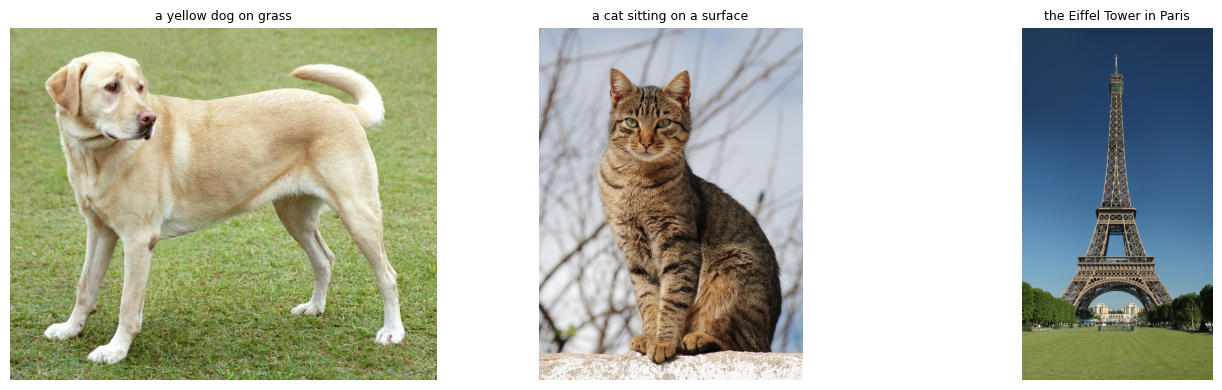

In [22]:
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

def load_image(url):
    # Wikimedia requires a User-Agent header, otherwise it blocks the request
    headers = {"User-Agent": "Mozilla/5.0 (workshop demo; educational use)"}
    response = requests.get(url, timeout=10, headers=headers)
    return Image.open(BytesIO(response.content)).convert("RGB")

# Three images with different content
image_urls = {
    "a yellow dog on grass": "https://upload.wikimedia.org/wikipedia/commons/2/26/YellowLabradorLooking_new.jpg",
    "a cat sitting on a surface": "https://upload.wikimedia.org/wikipedia/commons/4/4d/Cat_November_2010-1a.jpg",
    "the Eiffel Tower in Paris": "https://upload.wikimedia.org/wikipedia/commons/a/a8/Tour_Eiffel_Wikimedia_Commons.jpg",
}

print("Downloading images...")
images = {}
for desc, url in image_urls.items():
    try:
        images[desc] = load_image(url)
        print(f"  OK: {desc}")
    except Exception as e:
        print(f"  FAILED: {desc} ({e})")

fig, axes = plt.subplots(1, len(images), figsize=(14, 4))
for ax, (desc, img) in zip(axes, images.items()):
    ax.imshow(img)
    ax.set_title(desc, fontsize=9, wrap=True)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [23]:
from transformers import CLIPModel, CLIPProcessor

clip_model     = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to("cuda")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
print("CLIP loaded.")

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIP loaded.


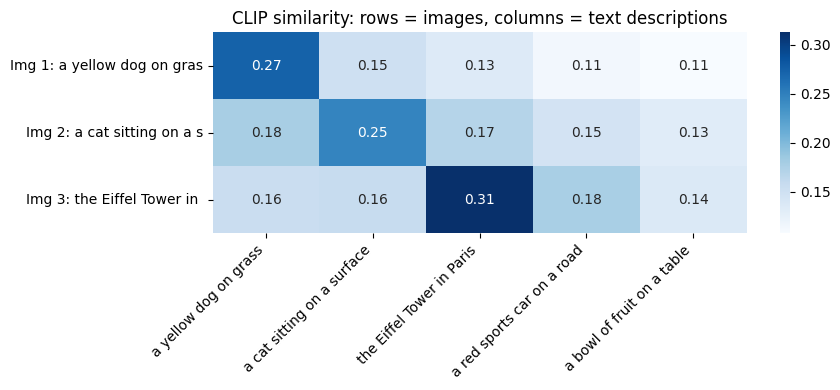

Each row is one image. The highest value in each row shows the best matching text.


In [26]:
import seaborn as sns
import torch.nn.functional as F

text_descriptions = list(images.keys()) + [
    "a red sports car on a road",
    "a bowl of fruit on a table",
]

image_list = list(images.values())
image_keys = list(images.keys())

text_inputs  = clip_processor(text=text_descriptions, return_tensors="pt", padding=True)
image_inputs = clip_processor(images=image_list, return_tensors="pt")

with torch.no_grad():
    # Go through the encoder and projection layer manually
    text_enc      = clip_model.text_model(
        input_ids      = text_inputs["input_ids"].to("cuda"),
        attention_mask = text_inputs["attention_mask"].to("cuda"),
    )
    text_features = clip_model.text_projection(text_enc.pooler_output)

    image_enc      = clip_model.vision_model(
        pixel_values = image_inputs["pixel_values"].to("cuda"),
    )
    image_features = clip_model.visual_projection(image_enc.pooler_output)

# Normalize to unit length (required for cosine similarity)
text_features  = F.normalize(text_features,  dim=-1)
image_features = F.normalize(image_features, dim=-1)

# Similarity matrix: shape [num_images, num_texts]
similarity = (image_features @ text_features.T).cpu()

short_texts = [t[:28] for t in text_descriptions]

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(
    similarity.numpy(),
    xticklabels=short_texts,
    yticklabels=[f"Img {i+1}: {k[:20]}" for i, k in enumerate(image_keys)],
    cmap="Blues", annot=True, fmt=".2f", ax=ax
)
ax.set_title("CLIP similarity: rows = images, columns = text descriptions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("Each row is one image. The highest value in each row shows the best matching text.")

---

### Exercise 3: CLIP Text-Image Matching

**Tasks:**
1. Add two new text descriptions to `text_descriptions` and run the cell again.
   Do the scores shift as you expect?
2. Try a description that is partially correct, for example
   "an animal with four legs". Which image does it match best?
3. Try a very wrong description like "a rocket launching into space".
   What score does it get compared to the correct ones?

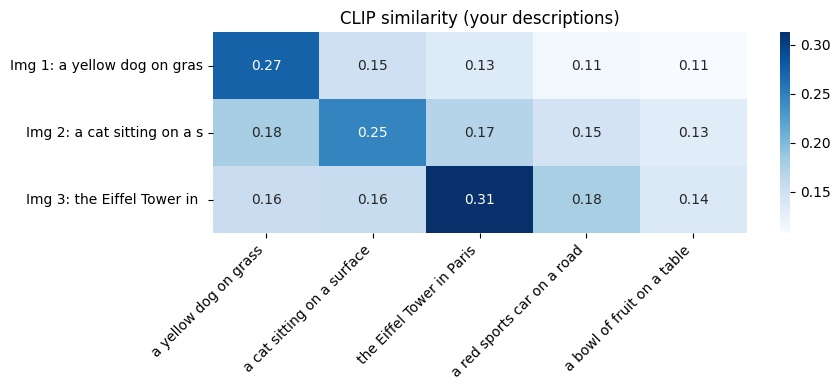

In [28]:
# TODO: add your own text descriptions to this list
my_text_descriptions = list(images.keys()) + [
    "a red sports car on a road",
    "a bowl of fruit on a table",
    # "an animal with four legs",
    # "a tall metal structure",
]

text_inputs  = clip_processor(text=my_text_descriptions, return_tensors="pt", padding=True)
image_inputs = clip_processor(images=image_list, return_tensors="pt")

with torch.no_grad():
    text_enc    = clip_model.text_model(
        input_ids      = text_inputs["input_ids"].to("cuda"),
        attention_mask = text_inputs["attention_mask"].to("cuda"),
    )
    text_feats = F.normalize(clip_model.text_projection(text_enc.pooler_output), dim=-1)

    image_enc = clip_model.vision_model(
        pixel_values = image_inputs["pixel_values"].to("cuda"),
    )
    image_feats = F.normalize(clip_model.visual_projection(image_enc.pooler_output), dim=-1)

sim = (image_feats @ text_feats.T).cpu()

short_texts2 = [t[:28] for t in my_text_descriptions]
fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(
    sim.numpy(),
    xticklabels=short_texts2,
    yticklabels=[f"Img {i+1}: {k[:20]}" for i, k in enumerate(image_keys)],
    cmap="Blues", annot=True, fmt=".2f", ax=ax
)
ax.set_title("CLIP similarity (your descriptions)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [29]:
del clip_model, clip_processor
gc.collect()
torch.cuda.empty_cache()
print("GPU memory freed.")

GPU memory freed.


---

## Part 2.4: Image Captioning with ViT + GPT-2

CLIP can compare images and text, but it cannot generate new text.
For image captioning, we need a model that can both read an image and write a sentence.

A common approach is to combine two models:
- A **Vision Transformer (ViT)** that encodes the image into a sequence of patch vectors
- A **GPT-2 decoder** that reads those patch vectors and generates a caption

The ViT splits the image into small square patches (e.g. 16x16 pixels).
Each patch is treated like a token.
The GPT-2 decoder then uses cross-attention to look at these patch tokens
while generating the output text word by word.

We use the same three images we downloaded in the previous section.

In [30]:
from transformers import VisionEncoderDecoderModel, ViTImageProcessor, AutoTokenizer

cap_model = VisionEncoderDecoderModel.from_pretrained("nlpconnect/vit-gpt2-image-captioning").to("cuda")
cap_processor = ViTImageProcessor.from_pretrained("nlpconnect/vit-gpt2-image-captioning")
cap_tokenizer = AutoTokenizer.from_pretrained("nlpconnect/vit-gpt2-image-captioning")
cap_model.eval()
print("Model loaded.")

config.json:   0%|          | 0.00/4.61k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/982M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/445 [00:00<?, ?it/s]

[transformers] VisionEncoderDecoderModel LOAD REPORT from: nlpconnect/vit-gpt2-image-captioning
Key                                                       | Status     |  | 
----------------------------------------------------------+------------+--+-
decoder.transformer.h.{0...11}.crossattention.masked_bias | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.attn.masked_bias           | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/982M [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/120 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Model loaded.


[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
[transformers] Both `max_new_tokens` (=30) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.
You may ignore this warning if your `pad_token_id` (50256) is identical to the `bos_token_id` (50256), `eos_token_id` (50256), or the `sep_token_id` (None), and your input is not padded.
[transformers] Both `max_new_tokens` (=30) and `max_length`(=20) seem to have been set. `m

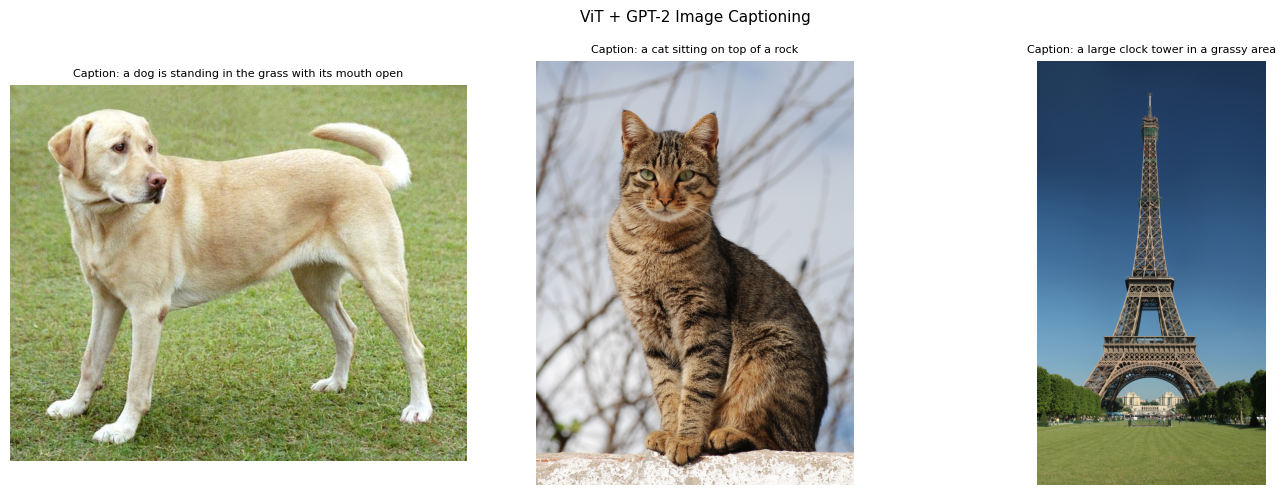

In [31]:
def generate_caption(image):
    pixel_values = cap_processor(images=[image], return_tensors="pt").pixel_values.to("cuda")
    with torch.no_grad():
        output_ids = cap_model.generate(pixel_values, max_new_tokens=30)
    caption = cap_tokenizer.decode(output_ids[0], skip_special_tokens=True)
    return caption.strip()

# Generate captions for all three images and show them side by side
fig, axes = plt.subplots(1, len(images), figsize=(14, 5))

for ax, (true_desc, img) in zip(axes, images.items()):
    caption = generate_caption(img)
    ax.imshow(img)
    ax.set_title(f"Caption: {caption}", fontsize=8, wrap=True)
    ax.set_xlabel(f"True: {true_desc[:35]}", fontsize=7)
    ax.axis("off")

plt.suptitle("ViT + GPT-2 Image Captioning", fontsize=11)
plt.tight_layout()
plt.show()

In [32]:
del cap_model, cap_processor, cap_tokenizer
gc.collect()
torch.cuda.empty_cache()
print("GPU memory freed.")

GPU memory freed.


---

## Part 2.5: Speech Recognition with Whisper

**Whisper** is a speech recognition model from OpenAI.
It was trained on 680,000 hours of audio from the internet
in 99 different languages.

Whisper uses an encoder-decoder architecture:
- The **encoder** converts the audio into a sequence of vectors
  (it uses a spectrogram as input, not raw audio)
- The **decoder** generates the text transcript token by token

Whisper is available in five sizes:
`tiny`, `base`, `small`, `medium`, and `large`.
We use `whisper-small` which is a good balance between speed and accuracy.

We load a short English speech sample from a public dataset (LibriSpeech)
and ask Whisper to transcribe it.

In [36]:
from datasets import load_dataset
import IPython.display as ipd
import numpy as np

# --- Option A: use the built-in LibriSpeech sample ---
librispeech   = load_dataset("hf-internal-testing/librispeech_asr_demo", "clean", split="validation")
sample        = librispeech[0]
audio_array   = sample["audio"]["array"]
sampling_rate = sample["audio"]["sampling_rate"]
ground_truth  = sample["text"]

print(f"Audio length : {len(audio_array) / sampling_rate:.1f} seconds")
print(f"Sampling rate: {sampling_rate} Hz")
print(f"Ground truth : {ground_truth}")

# Play the audio directly in the notebook
ipd.display(ipd.Audio(audio_array, rate=sampling_rate))

Audio length : 5.9 seconds
Sampling rate: 16000 Hz
Ground truth : MISTER QUILTER IS THE APOSTLE OF THE MIDDLE CLASSES AND WE ARE GLAD TO WELCOME HIS GOSPEL


In [37]:
from transformers import pipeline

# Other Whisper model sizes for Colab T4:
#   "openai/whisper-tiny"    39M params, fastest
#   "openai/whisper-base"    74M params
#   "openai/whisper-small"   244M params, good for English
#   "openai/whisper-medium"  769M params, multilingual
#   "openai/whisper-large-v3" 1.5B params, best quality

asr = pipeline(
    "automatic-speech-recognition",
    model="openai/whisper-small",
    device=0,
)

result = asr({"array": audio_array, "sampling_rate": sampling_rate})

print(f"Ground truth  : {ground_truth}")
print(f"Transcription : {result['text']}")
print()
print("Note: Whisper-small may make small errors on proper names or unusual words.")

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

Ground truth  : MISTER QUILTER IS THE APOSTLE OF THE MIDDLE CLASSES AND WE ARE GLAD TO WELCOME HIS GOSPEL
Transcription :  Mr. Quilter is the Apostle of the Middle Classes, and we are glad to welcome his Gospel.

Note: Whisper-small may make small errors on proper names or unusual words.


In [38]:
del asr
gc.collect()
torch.cuda.empty_cache()
print("GPU memory freed.")

GPU memory freed.


---

## Optional: Text-to-Image with Stable Diffusion

*Run this section only if there is time left. It takes about 2 to 3 minutes to load.*

A **diffusion model** generates images by starting with random noise
and slowly removing that noise step by step, guided by a text prompt.

This is very different from autoregressive generation:
the model does not produce pixels one by one.
Instead, it runs many denoising steps across the full image at once.

We use `stable-diffusion-2-1-base` in float16 precision.
This uses about 4 GB of GPU memory and fits on the T4.

In [39]:
# Optional: run only if time allows
!pip install -q diffusers accelerate

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Generating image...


  0%|          | 0/20 [00:00<?, ?it/s]

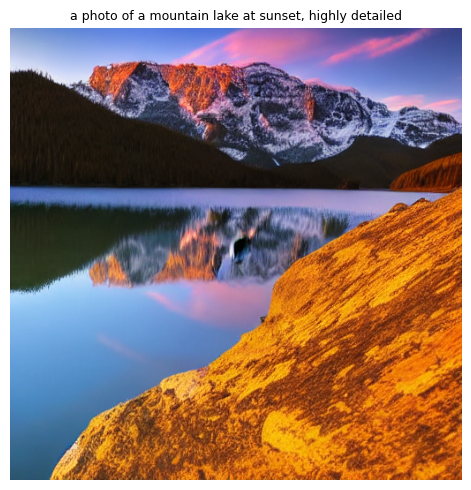

In [42]:
from diffusers import StableDiffusionPipeline
import torch
import matplotlib.pyplot as plt

sd_pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    #"dreamlike-art/dreamlike-photoreal-2.0",
    torch_dtype=torch.float16,
).to("cuda")

# TODO: change the prompt to anything you like
prompt = "a photo of a mountain lake at sunset, highly detailed"

print("Generating image...")
image = sd_pipe(prompt, num_inference_steps=20).images[0]

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.axis("off")
plt.title(prompt, fontsize=9)
plt.tight_layout()
plt.show()

In [43]:
del sd_pipe
gc.collect()
torch.cuda.empty_cache()

---

## Wrapping Up

In this notebook you have:

- Generated text with GPT-2 and seen how sampling parameters change the output
- Translated and summarized text with T5 using task prefixes
- Compared images and text descriptions using CLIP embeddings
- Generated image captions with a ViT + GPT-2 model
- Transcribed speech to text with Whisper

**Key points:**

- Decoder models generate text one token at a time. Temperature and top-k control how creative or focused the output is.
- Encoder-decoder models like T5 are better for tasks where the output is closely tied to the input, such as translation and summarization.
- CLIP shows that different data types (text, images) can be mapped to the same vector space, making cross-modal comparison possible.
- Models like Whisper and ViT+GPT-2 combine encoders for one modality with decoders for another.

**Part 3** covers inference servers, tool use, and agentic systems.

In [ ]:
# Run this cell before opening the Part 3 notebook
import IPython
app = IPython.Application.instance()
app.kernel.do_shutdown(True)